START HERE

In [488]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [695]:
PROJECT_ROOT = Path.cwd().resolve().parents[0]
PROCESSED_DATA_DIR = PROJECT_ROOT / 'data' / 'processed'
OUTPUT_DIR = PROJECT_ROOT / 'figures'

In [ ]:
cell_authors = pd.read_csv(PROCESSED_DATA_DIR / 'cell_processed_author_data.csv')
nature_authors = pd.read_csv(PROCESSED_DATA_DIR / 'nature_processed_author_data.csv')

In [707]:
cell_authors['publication'] = 'Cell'
nature_authors['publication'] = 'Nature'
cell_authors = cell_authors.set_index('PMID')
nature_authors = nature_authors.set_index('PMID')

In [708]:
# many publications especially at earlier time points only list the affiliation for the first author
# set that affiliation for authors with no affiliation listed
cell_authors['primary_country'] = cell_authors['primary_country'].replace('No affiliation', np.nan)
cell_authors['primary_country'] = cell_authors['primary_country'].fillna(
    cell_authors.groupby('PMID')['primary_country'].transform('first'))

nature_authors['primary_country'] = nature_authors['primary_country'].replace('No affiliation', np.nan)
nature_authors['primary_country'] = nature_authors['primary_country'].fillna(
    nature_authors.groupby('PMID')['primary_country'].transform('first'))

In [709]:
all_authors = pd.concat([cell_authors, nature_authors])

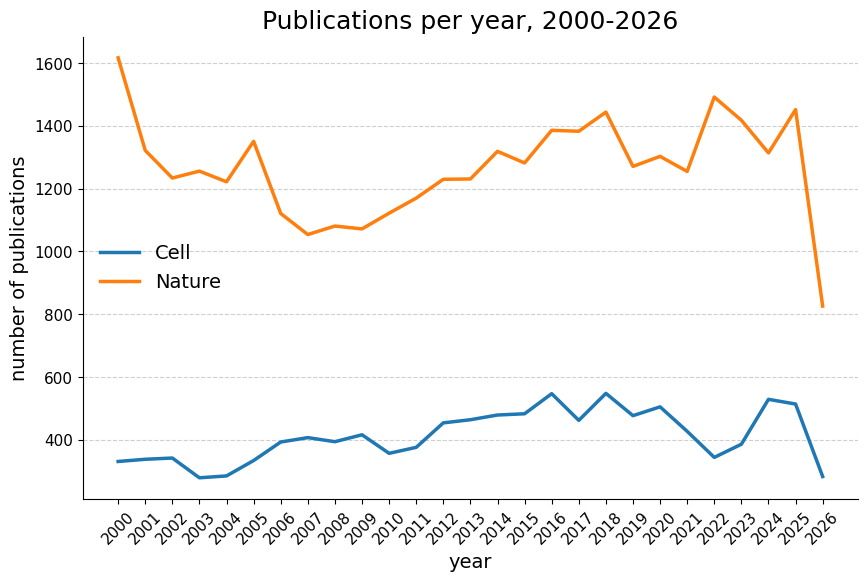

In [710]:
# plot number of publications over time
plot_df = all_authors.reset_index().groupby(['year', 'publication'])['PMID'].nunique().reset_index()
plt.figure(figsize=(10,6))
sns.lineplot(data = plot_df, x = 'year', y = 'PMID', hue = 'publication',
             linewidth = 2.5)
plt.title('Publications per year, 2000-2026', fontsize = 18)
plt.ylabel('number of publications', fontsize = 14)
plt.xlabel('year', fontsize = 14)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.yticks(fontsize = 11)
plt.xticks(plot_df['year'].unique(), rotation=45, fontsize = 11)
plt.legend(frameon=False, fontsize = 14)
sns.despine()
plt.show()

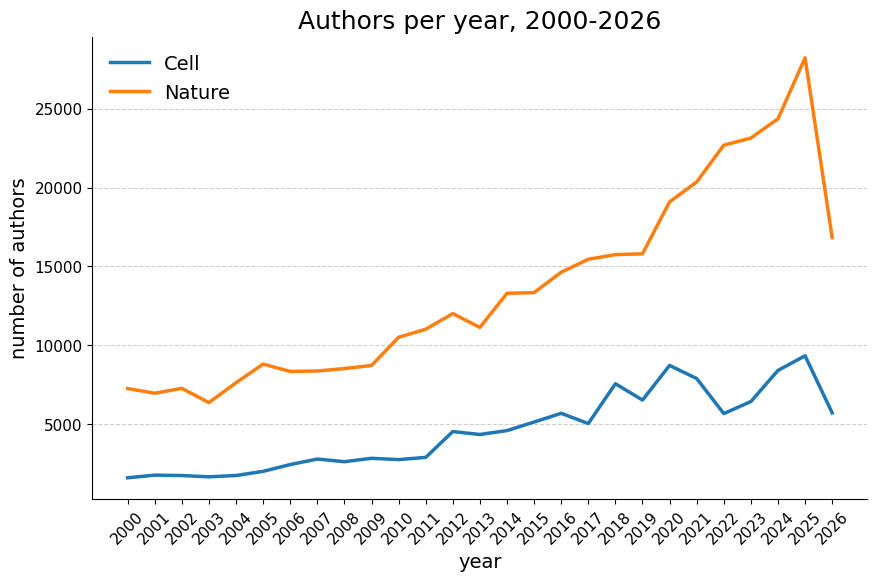

In [711]:
# plot number of authors over time
plot_df = all_authors.reset_index().groupby(['year', 'publication']).size().reset_index(name='num_authors')
plt.figure(figsize=(10,6))
sns.lineplot(data = plot_df, x = 'year', y = 'num_authors', hue = 'publication',
             linewidth = 2.5)
plt.title('Authors per year, 2000-2026', fontsize = 18)
plt.ylabel('number of authors', fontsize = 14)
plt.xlabel('year', fontsize = 14)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.yticks(fontsize = 11)
plt.xticks(plot_df['year'].unique(), rotation=45, fontsize = 11)
plt.legend(frameon=False, fontsize = 14)
sns.despine()
plt.show()

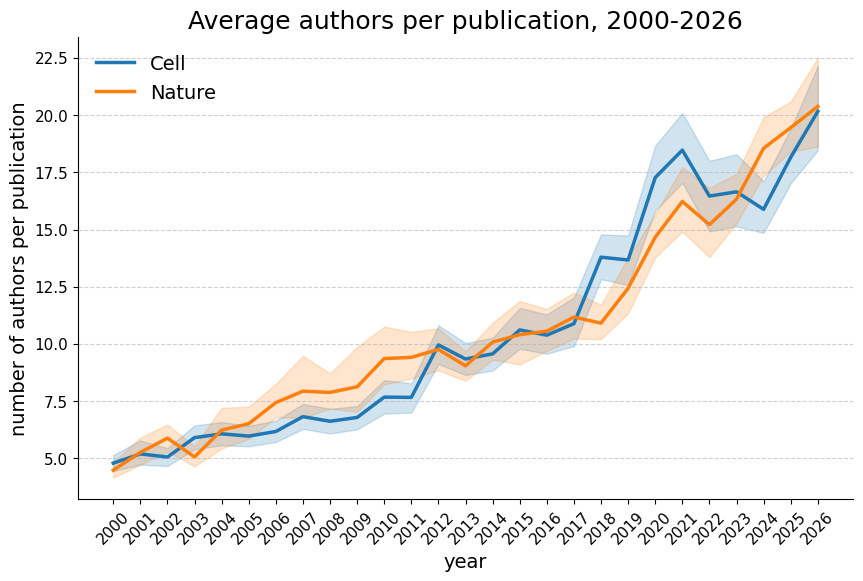

In [702]:
# plot average number of authors per publication over time
plot_df = all_authors.reset_index().groupby(['year', 'publication', 'PMID']).size().reset_index(name='authors_per_paper')
plt.figure(figsize=(10,6))
sns.lineplot(data = plot_df, x = 'year', y = 'authors_per_paper', hue = 'publication',
             linewidth = 2.5,
             estimator = 'mean')
plt.title('Average authors per publication, 2000-2026', fontsize = 18)
plt.ylabel('number of authors per publication', fontsize = 14)
plt.xlabel('year', fontsize = 14)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.yticks(fontsize = 11)
plt.xticks(plot_df['year'].unique(), rotation=45, fontsize = 11)
plt.legend(frameon=False, fontsize = 14)
sns.despine()
plt.show()

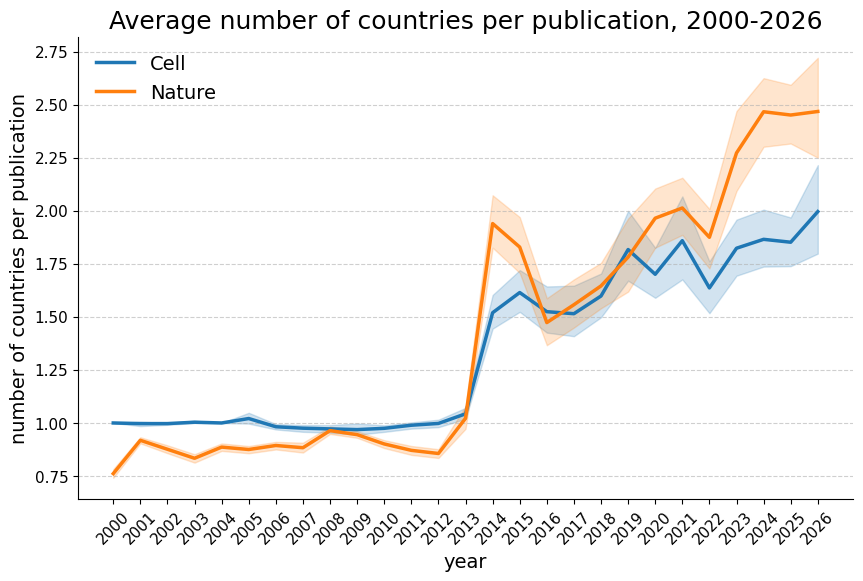

In [712]:
# plot average number of countries per publication over time
plot_df = all_authors.reset_index().groupby(['year', 'publication', 'PMID'])['primary_country'].nunique().reset_index(name='countries_per_paper')
plt.figure(figsize=(10,6))
sns.lineplot(data = plot_df, x = 'year', y = 'countries_per_paper', hue = 'publication',
             linewidth = 2.5,
             estimator = 'mean')
plt.title('Average number of countries per publication, 2000-2026', fontsize = 18)
plt.ylabel('number of countries per publication', fontsize = 14)
plt.xlabel('year', fontsize = 14)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.yticks(fontsize = 11)
plt.xticks(plot_df['year'].unique(), rotation=45, fontsize = 11)
plt.legend(frameon=False, fontsize = 14)
sns.despine()
plt.show()

In [713]:
# since affiliations were not fully recored before 2014, restrict
# rest of analysis to post 2014 data. Also restrict to countries that
# appear more than 25 times

filtered = all_authors[all_authors['year'] >= 2014].dropna()

filtered = filtered[filtered['primary_country'].map(filtered['primary_country'].value_counts() > 25)]



In [ ]:
# 1. Drop duplicates to ensure we only count a country once per PMID 
# (e.g., if a paper has 3 USA authors, we only want USA listed once for that paper)
df_unique = filtered.reset_index().drop_duplicates(subset=['PMID', 'primary_country'])

# 2. Merge the dataframe with itself on PMID to create all country pairs
pairs = df_unique.merge(df_unique, on='PMID', suffixes=('_target', '_partner'))

# 3. Filter out self-matches (we don't want to count USA pairing with USA)
pairs = pairs[pairs['primary_country_target'] != pairs['primary_country_partner']]

# 4. Group by the two country columns and count the occurrences
co_occurrences = pairs.groupby(['primary_country_target', 'primary_country_partner']).size().reset_index(name='Count')

# 5. Sort the results so the highest counts appear first
co_occurrences = co_occurrences.sort_values(by=['primary_country_target', 'Count'], ascending=[True, False])

co_occurrences[co_occurrences['primary_country_target'] == 'Japan']

,primary_country_target,primary_country_partner,Count
3303,Japan,USA,743
3302,Japan,UK,306
3245,Japan,Germany,305
3228,Japan,China,209
3242,Japan,France,194
...,...,...,...
3277,Japan,Republic of Singapore,1
3280,Japan,Rwanda,1
3282,Japan,Scotland,1
3285,Japan,Sierra Leone,1


In [672]:
matrix = co_occurrences.pivot(index='primary_country_target', columns='primary_country_partner', values='Count').fillna(0)

In [752]:
# get the top 10 countries by number of publications that they feature on
top_5 = list(filtered['primary_country'].value_counts().iloc[0:5].index)

In [780]:
# drop duplicates based on PMID and country so that only a single country
# is preserved per PMID
df_unique = filtered.reset_index().drop_duplicates(subset=['PMID', 'primary_country']).copy()

# groupby PMID and count countries to get unique countries per paper
df_unique['total_countries'] = df_unique.groupby('PMID')['primary_country'].transform('count')

# for each row, subtract 1 to get the number of countries aside from
# that country that contributed to the paper
df_unique['other_countries'] = df_unique['total_countries'] - 1

# for each primary country, compute crosstab to get frequency of collaborations
# with other countries
collaboration_counts = pd.crosstab(
    index=df_unique['primary_country'], 
    columns=df_unique['other_countries']
)

#sum up values over 15 to get an aggregate value for papers with over
# 15 collaborating countries
cond = collaboration_counts.columns[collaboration_counts.columns > 15]
collaboration_counts['>15'] = collaboration_counts[cond].sum(axis=1)
collaboration_counts = collaboration_counts.drop(columns = cond)
collaboration_counts

# normalize the collab counts by the sum of papers
norm_collab_counts = collaboration_counts.div(collaboration_counts.sum(axis=1),axis=0)

norm_collab_counts

other_countries,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,>15
primary_country,,,,,,,,,,,,,,,,,
Argentina,0.018018,0.117117,0.135135,0.063063,0.090090,0.090090,0.072072,0.036036,0.063063,0.027027,0.009009,0.027027,0.027027,0.036036,0.000000,0.009009,0.180180
Australia,0.067257,0.230973,0.184956,0.122124,0.096460,0.056637,0.042478,0.031858,0.032743,0.027434,0.011504,0.013274,0.013274,0.010619,0.004425,0.004425,0.049558
Austria,0.108929,0.226786,0.178571,0.089286,0.048214,0.046429,0.051786,0.050000,0.021429,0.019643,0.016071,0.012500,0.007143,0.014286,0.014286,0.014286,0.080357
Bangladesh,0.000000,0.235294,0.176471,0.058824,0.117647,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.411765
Belgium,0.045455,0.181818,0.201818,0.141818,0.081818,0.065455,0.049091,0.041818,0.020000,0.032727,0.018182,0.016364,0.009091,0.016364,0.009091,0.009091,0.060000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
United Arab Emirates,0.037736,0.207547,0.132075,0.056604,0.056604,0.056604,0.000000,0.000000,0.113208,0.000000,0.037736,0.000000,0.037736,0.075472,0.018868,0.037736,0.132075
Venezuela,0.000000,0.000000,0.000000,0.133333,0.000000,0.066667,0.000000,0.000000,0.000000,0.133333,0.000000,0.000000,0.133333,0.000000,0.000000,0.066667,0.466667
Vietnam,0.000000,0.000000,0.111111,0.000000,0.111111,0.111111,0.000000,0.000000,0.000000,0.111111,0.000000,0.000000,0.000000,0.055556,0.055556,0.000000,0.444444


In [ ]:
# transform normalized counts to long format for plotting
long_counts = norm_collab_counts.reset_index().melt(
    id_vars = 'primary_country',
    var_name = 'num_collab_countries',
    value_name = 'proportion'
)
# change value to str for plotting appropriately
long_counts['num_collab_countries'] = long_counts['num_collab_countries'].astype(str)

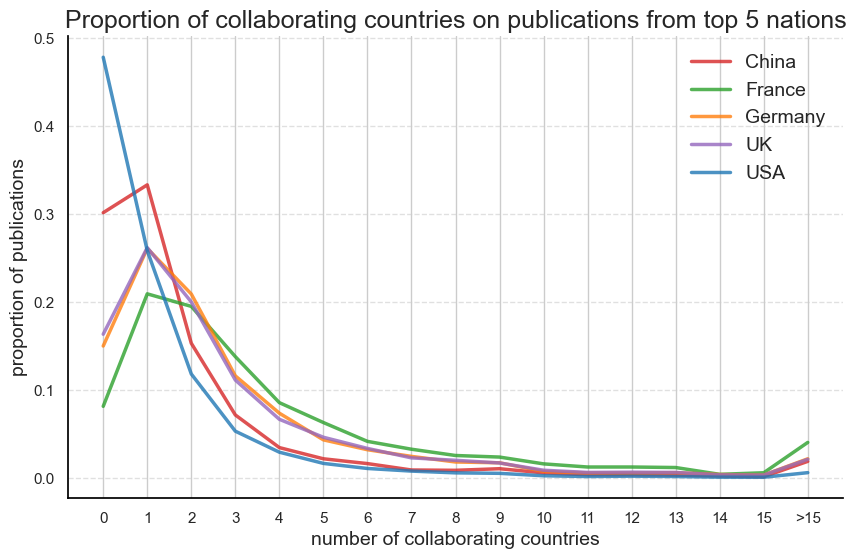

In [795]:
cond = long_counts['primary_country'].isin(top_5)

country_colors = {
    'USA': '#1f77b4',     # Hex code for a nice blue
    'Germany': '#ff7f0e',  # Orange
    'China': '#d62728',   # Red
    'France': '#2ca02c',   # Green
    'UK': '#9467bd', # Purple
}


plt.figure(figsize=(10,6))
ax = sns.lineplot(
    data = long_counts[cond],
    x = 'num_collab_countries',
    y = 'proportion',
    hue = 'primary_country',
    linewidth = 2.5,
    alpha = 0.8,
    palette= country_colors
)
plt.title('Proportion of collaborating countries on publications from top 5 nations', fontsize = 18)
plt.ylabel('proportion of publications', fontsize = 14)
plt.xlabel('number of collaborating countries', fontsize = 14)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.yticks(fontsize = 11)
plt.xticks(rotation=0, fontsize = 11)
plt.legend(frameon=False, fontsize = 14)
sns.despine()
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')
plt.show()
